# 🕳️ Pothole Detection using YOLOv11
Local Jupyter setup — train, evaluate, and predict.

## 1. Install Dependencies

In [1]:
!pip install ultralytics pillow --quiet

## 2. Verify Folder Structure

In [2]:
import os
from pathlib import Path

BASE_DIR = Path(os.getcwd())
train_images = BASE_DIR / 'train' / 'images'
train_labels = BASE_DIR / 'train' / 'labels'
valid_images = BASE_DIR / 'valid' / 'images'
valid_labels = BASE_DIR / 'valid' / 'labels'

for folder in [train_images, train_labels, valid_images, valid_labels]:
    count = len(list(folder.glob('*.*'))) if folder.exists() else 0
    status = '✅' if folder.exists() else '❌ MISSING'
    print(f"{status}  {folder.relative_to(BASE_DIR)}  ({count} files)")

✅  train\images  (1581 files)
✅  train\labels  (1581 files)
✅  valid\images  (396 files)
✅  valid\labels  (396 files)


## 3. Check Unique Image Sizes

In [3]:
from PIL import Image

unique_sizes = set()
for img_path in train_images.glob('*.*'):
    try:
        img = Image.open(img_path)
        unique_sizes.add(img.size)
    except Exception:
        pass

print(f"Total training images: {len(list(train_images.glob('*.*')))}")
print("Unique image sizes (W x H):")
for w, h in sorted(unique_sizes):
    print(f"  {w} x {h}")

Total training images: 1581
Unique image sizes (W x H):
  135 x 180
  169 x 225
  200 x 150
  200 x 200
  204 x 170
  225 x 150
  225 x 300
  240 x 135
  240 x 180
  243 x 330
  250 x 333
  260 x 260
  267 x 179
  267 x 226
  269 x 178
  270 x 176
  280 x 220
  295 x 188
  299 x 129
  300 x 168
  300 x 180
  300 x 195
  300 x 196
  300 x 199
  300 x 200
  300 x 202
  300 x 212
  300 x 224
  300 x 225
  300 x 300
  300 x 356
  300 x 357
  300 x 397
  300 x 399
  300 x 400
  300 x 403
  300 x 440
  300 x 442
  300 x 444
  300 x 450
  300 x 451
  300 x 533
  303 x 300
  306 x 588
  320 x 240
  320 x 294
  324 x 216
  325 x 216
  335 x 300
  336 x 300
  345 x 300
  347 x 270
  350 x 234
  350 x 237
  350 x 378
  360 x 300
  365 x 205
  368 x 206
  370 x 204
  370 x 300
  371 x 277
  380 x 312
  382 x 300
  383 x 300
  396 x 300
  399 x 300
  400 x 140
  400 x 148
  400 x 156
  400 x 168
  400 x 173
  400 x 174
  400 x 175
  400 x 176
  400 x 178
  400 x 184
  400 x 199
  400 x 206
  400 x 

## 4. Create data.yaml

In [4]:
yaml_path = BASE_DIR / 'data.yaml'

content = f"""# Pothole Detection - YOLOv11
train: {train_images}
val: {valid_images}

nc: 1
names:
  0: pothole
"""

with open(yaml_path, 'w') as f:
    f.write(content)

print('data.yaml created successfully!')
print('\nContents:')
print(content)

data.yaml created successfully!

Contents:
# Pothole Detection - YOLOv11
train: C:\Users\ASUS\OneDrive\Desktop\Pothole Detection\data\train\images
val: C:\Users\ASUS\OneDrive\Desktop\Pothole Detection\data\valid\images

nc: 1
names:
  0: pothole



## 5. Train YOLOv11 Model (50 Epochs)

In [5]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')

results = model.train(
    data=str(BASE_DIR / 'data.yaml'),
    epochs=50,
    imgsz=640,
    batch=16,
    project=str(BASE_DIR / 'pothole_yolo11'),
    name='exp1',
    val=True,
    plots=True,
    dropout=0.3,
    patience=10
)

print('✅ Training complete!')

New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.26  Python-3.11.9 torch-2.11.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\ASUS\OneDrive\Desktop\Pothole Detection\data\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.3, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mo

## 6. Display Training Results

In [3]:
from ultralytics import YOLO
from pathlib import Path
import os

BASE_DIR = Path(os.getcwd())
project_dir = BASE_DIR / 'pothole_yolo11'

# Find the exp folder that actually has weights
exp_with_weights = None
for exp in sorted(project_dir.glob('exp*'), key=lambda p: p.stat().st_mtime, reverse=True):
    weights_dir = exp / 'weights'
    if list(weights_dir.glob('*.pt')):
        exp_with_weights = exp
        break

if exp_with_weights is None:
    raise FileNotFoundError("No experiment folder with .pt weights found!")

weights_dir = exp_with_weights / 'weights'
print(f"✅ Found weights in: {exp_with_weights.name}")

best_model = weights_dir / 'best.pt'
last_model = weights_dir / 'last.pt'
model_path = best_model if best_model.exists() else last_model
print(f"Using: {model_path.name}")

model = YOLO(str(model_path))

# Run prediction on a validation image
valid_imgs = list((BASE_DIR / 'valid' / 'images').glob('*.jpg'))
if valid_imgs:
    model.predict(
        source=str(valid_imgs[0]),
        imgsz=640,
        conf=0.25,
        save=True
    )
    print('✅ Prediction complete!')
else:
    print('No validation images found.')

✅ Found weights in: exp14
Using: best.pt

image 1/1 C:\Users\ASUS\OneDrive\Desktop\Pothole Detection\data\valid\images\pothole_10.jpg: 448x640 8 potholes, 635.3ms
Speed: 31.1ms preprocess, 635.3ms inference, 80.2ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\ASUS\OneDrive\Desktop\Pothole Detection\data\runs\detect\predict
✅ Prediction complete!


## 8. Display Prediction Result

Showing 1 prediction(s):


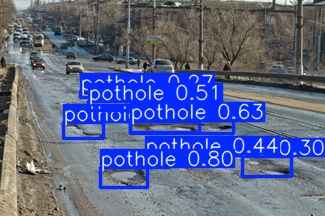

In [11]:
import glob
from IPython.display import Image as IPImage, display

pred_results = sorted(glob.glob(str(BASE_DIR / 'runs' / 'detect' / 'predict*' / '*.jpg')))
pred_results += sorted(glob.glob(str(BASE_DIR / 'runs' / 'detect' / 'predict*' / '*.png')))

if pred_results:
    print(f'Showing {len(pred_results)} prediction(s):')
    for p in pred_results:
        display(IPImage(filename=p, width=700))
else:
    print('No prediction results found.')

## 10. (Optional) Zip and Save Results

In [7]:
import shutil

exp_dir = BASE_DIR / 'pothole_yolo11' / 'exp1'
zip_out = BASE_DIR / 'exp1_backup'

if exp_dir.exists():
    shutil.make_archive(str(zip_out), 'zip', str(exp_dir))
    print(f'✅ Results zipped to: {zip_out}.zip')
else:
    print('Training results directory not found.')

✅ Results zipped to: C:\Users\ASUS\OneDrive\Desktop\Pothole Detection\data\exp1_backup.zip



0: 448x640 5 potholes, 117.6ms
Speed: 37.1ms preprocess, 117.6ms inference, 13.0ms postprocess per image at shape (1, 3, 448, 640)


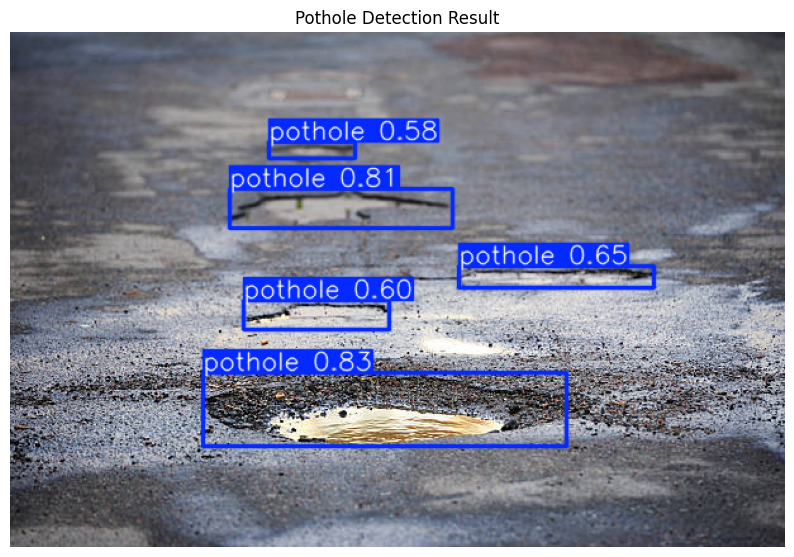

In [4]:
# Install ultralytics if not already installed
# !pip install ultralytics

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load your trained model
# 👉 Replace with your model path
model = YOLO("pothole_yolo11/exp14/weights/best.pt")

# Load image
# 👉 Replace with your image path
image_path = "istockphoto-183362998-612x612.jpg"
img = cv2.imread(image_path)

# Run detection
results = model(img)

# Plot results
annotated_img = results[0].plot()

# Convert BGR → RGB for display
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(10,8))
plt.imshow(annotated_img)
plt.axis("off")
plt.title("Pothole Detection Result")
plt.show()

In [ ]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".pt"):
            print(os.path.join(root, file))